# $2^n$ 人トーナメント問題

## 設定
- $2^n$ 人の参加者を強さの順に $1 \sim 2^n$ で番号付け（1が最強，$2^n$ が最弱）
- 初期配置はランダム（全ての配置が等確率）
- 強い方が必ず勝つ（確定トーナメント）
- 優勝者（1位）は常に参加者番号 1 の人

## 問 (1)
2位になった人は，平均すると何番目に強いか？

## 問 (2)
2位になった人の強さの95%確率区間を求めよ。

In [11]:
# パッケージのインストール（初回のみ）
import Pkg
for pkg in ["SpecialFunctions", "Plots"]
    haskey(Pkg.project().dependencies, pkg) || Pkg.add(pkg)
end

using Statistics, Random, Printf
using SpecialFunctions: lgamma
using Plots,PlotsGRBackendFontJaEmoji
gr()

# ログ二項係数（大きな n でもオーバーフローしない）
function logbinom(n::Int, k::Int)::Float64
    (k < 0 || k > n || n < 0) && return -Inf
    lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)
end

println("パッケージ読み込み完了")

パッケージ読み込み完了


## 理論解析

### 2位になる人の特徴

$2^n$ 人のトーナメントは $n$ ラウンドあり，1番強い人は全ラウンド勝利して優勝する．

$$\text{2位の人} = \text{決勝で1番に負けた人} = \text{1番がいない側のブラケットの優勝者}$$

ブラケットを2つに分割すると：
- **1番のいる側**：1番 ＋ $\{2,\ldots,2^n\}$ からランダムに選ばれた $2^{n-1}-1$ 人
- **もう一方の側**：$\{2,\ldots,2^n\}$ からランダムに選ばれた $m = 2^{n-1}$ 人

2位の人の順位 $R$ ＝「$\{2,3,\ldots,2^n\}$（$N-1$ 個）から $m = N/2$ 人を**無作為非復元抽出**したときの**最小値**」

### 問(1)の理論値

$\{1,2,\ldots,M\}$ から $m$ 人を無作為非復元抽出したときの最小値の期待値は $\dfrac{M+1}{m+1}$．

$\{2,\ldots,N\}$（$N-1$ 個）から $m = N/2$ 人を選ぶ場合は $+1$ のシフトがあるので：

$$\boxed{E[R] = 1 + \frac{N}{m+1} = 1 + \frac{2^n}{2^{n-1}+1} = \frac{3 \cdot 2^{n-1}+1}{2^{n-1}+1}}$$

$n \to \infty$ のとき $E[R] \to 3$（2位の人は平均的に「3番目に強い人」に近づく）．

### 問(2)の理論：確率質量関数と確率区間

$$P(R = k) = \frac{\binom{N-k}{m-1}}{\binom{N-1}{m}}, \quad k = 2, 3, \ldots, \frac{N}{2}+1$$

累積分布関数（CDF）：

$$F(k) = P(R \leq k) = 1 - \frac{\binom{N-k}{m}}{\binom{N-1}{m}}, \quad k = 2, \ldots, \frac{N}{2}$$

**95%確率区間** $[L, U]$：$P(L \leq R \leq U) \geq 0.95$ となる最小の区間
- 下限 $L$：$F(L) \geq 0.025$ となる最小の $k$
- 上限 $U$：$F(U) \geq 0.975$ となる最小の $k$

**漸近的な分布**：$n$ が大きいとき，$P(R = k+1)/P(R = k) \approx 1/2$ となるため，$R-1$ は幾何分布 $\mathrm{Geom}(1/2)$ に近づく．したがって大きな $n$ では 95%確率区間 $\approx [2, 7]$．

In [12]:
# ===== 問(1) 理論値の計算 =====

function theoretical_mean(n::Int)::Float64
    N = 2^n
    m = N ÷ 2
    return 1.0 + N / (m + 1)
end

println("問(1) 理論値 E[2位の順位]")
println("式: E[R] = 1 + 2^n / (2^(n-1) + 1)")
println()
println("  n |      N | E[R] (理論値) | 分数表示")
println("----+--------+--------------+---------------------")
for n in 1:12
    N = 2^n
    m = N ÷ 2
    num = 3m + 1
    den = m + 1
    @printf(" %2d | %6d |    %8.4f  | (%d*2^%d+1)/(2^%d+1)\n",
            n, N, theoretical_mean(n), 3, n-1, n-1)
end
println()
println("n → ∞ のとき E[R] → 3")

問(1) 理論値 E[2位の順位]
式: E[R] = 1 + 2^n / (2^(n-1) + 1)

  n |      N | E[R] (理論値) | 分数表示
----+--------+--------------+---------------------
  1 |      2 |      2.0000  | (3*2^0+1)/(2^0+1)
  2 |      4 |      2.3333  | (3*2^1+1)/(2^1+1)
  3 |      8 |      2.6000  | (3*2^2+1)/(2^2+1)
  4 |     16 |      2.7778  | (3*2^3+1)/(2^3+1)
  5 |     32 |      2.8824  | (3*2^4+1)/(2^4+1)
  6 |     64 |      2.9394  | (3*2^5+1)/(2^5+1)
  7 |    128 |      2.9692  | (3*2^6+1)/(2^6+1)
  8 |    256 |      2.9845  | (3*2^7+1)/(2^7+1)
  9 |    512 |      2.9922  | (3*2^8+1)/(2^8+1)
 10 |   1024 |      2.9961  | (3*2^9+1)/(2^9+1)
 11 |   2048 |      2.9980  | (3*2^10+1)/(2^10+1)
 12 |   4096 |      2.9990  | (3*2^11+1)/(2^11+1)

n → ∞ のとき E[R] → 3


In [13]:
# ===== シミュレーション関数 =====

# 1回のトーナメントを実行し，2位の順位を返す
function simulate_one_tournament(n::Int)::Int
    current = randperm(2^n)
    while length(current) > 2
        current = [min(current[2i-1], current[2i]) for i in 1:length(current)÷2]
    end
    return max(current[1], current[2])  # 2位 = 決勝の敗者 = 大きい方の番号
end

# num_sims 回シミュレーションして2位の順位一覧を返す
function simulate_runner_up(n::Int, num_sims::Int=100_000)::Vector{Int}
    return [simulate_one_tournament(n) for _ in 1:num_sims]
end

println("シミュレーション関数を定義しました")

シミュレーション関数を定義しました


In [14]:
# ===== 問(1) シミュレーションと理論値の比較 =====

println("問(1) シミュレーションと理論値の比較 (各 n: 200,000 回)")
println()
println("  n |      N | 理論値 E[R] | シミュ平均 |     差")
println("----+--------+------------+-----------+--------")

sim_results = Dict{Int, Vector{Int}}()
Random.seed!(42)

for n in 1:10
    r = simulate_runner_up(n, 200_000)
    sim_results[n] = r
    theo = theoretical_mean(n)
    sim_m = mean(r)
    @printf(" %2d | %6d |   %8.5f |  %8.5f | %+.5f\n",
            n, 2^n, theo, sim_m, sim_m - theo)
end

問(1) シミュレーションと理論値の比較 (各 n: 200,000 回)

  n |      N | 理論値 E[R] | シミュ平均 |     差
----+--------+------------+-----------+--------
  1 |      2 |    2.00000 |   2.00000 | +0.00000
  2 |      4 |    2.33333 |   2.33261 | -0.00072
  3 |      8 |    2.60000 |   2.60074 | +0.00074
  4 |     16 |    2.77778 |   2.77396 | -0.00382
  5 |     32 |    2.88235 |   2.88585 | +0.00349
  6 |     64 |    2.93939 |   2.93952 | +0.00012
  7 |    128 |    2.96923 |   2.96686 | -0.00237
  8 |    256 |    2.98450 |   2.98914 | +0.00464
  9 |    512 |    2.99222 |   2.99498 | +0.00277
 10 |   1024 |    2.99610 |   3.00508 | +0.00897


In [15]:
# ===== 問(2) 理論的確率分布と95%確率区間 =====

# PMF: P(R = k) = C(N-k, m-1) / C(N-1, m)
function pmf_runner_up(n::Int)
    N = 2^n
    m = N ÷ 2
    log_denom = logbinom(N - 1, m)
    k_range = 2:(N - m + 1)
    probs = [exp(logbinom(N - k, m - 1) - log_denom) for k in k_range]
    return collect(k_range), probs
end

# CDF: F(k) = 1 - C(N-k, m) / C(N-1, m)
function cdf_R(n::Int, k::Int)::Float64
    N = 2^n
    m = N ÷ 2
    k < 2 && return 0.0
    k >= N - m + 1 && return 1.0
    return 1.0 - exp(logbinom(N - k, m) - logbinom(N - 1, m))
end

# 理論的95%確率区間 [L, U]: P(L ≤ R ≤ U) ≥ 0.95
function theoretical_ci95(n::Int)
    N = 2^n
    m = N ÷ 2
    k_max = N - m + 1
    L = 2
    U = k_max
    for k in 2:k_max
        if cdf_R(n, k) >= 0.025
            L = k; break
        end
    end
    for k in 2:k_max
        if cdf_R(n, k) >= 0.975
            U = k; break
        end
    end
    coverage = cdf_R(n, U) - (L > 2 ? cdf_R(n, L - 1) : 0.0)
    return L, U, coverage
end

println("問(2) 理論的95%確率区間")
println("（P(L ≤ R ≤ U) ≥ 0.95 を満たす [L, U]，下限は2.5%点，上限は97.5%点）")
println()
println("  n |      N | E[R]理論値 | 下限 L | 上限 U | カバレッジ")
println("----+--------+-----------+--------+--------+-----------")
for n in 1:12
    L, U, cov = theoretical_ci95(n)
    E = theoretical_mean(n)
    @printf(" %2d | %6d |  %8.4f  |   %4d |   %4d |   %.4f\n",
            n, 2^n, E, L, U, cov)
end
println()
println("注: n が十分大きいと 95%確率区間 ≈ [2, 7] に収束する")

問(2) 理論的95%確率区間
（P(L ≤ R ≤ U) ≥ 0.95 を満たす [L, U]，下限は2.5%点，上限は97.5%点）

  n |      N | E[R]理論値 | 下限 L | 上限 U | カバレッジ
----+--------+-----------+--------+--------+-----------
  1 |      2 |    2.0000  |      2 |      2 |   1.0000
  2 |      4 |    2.3333  |      2 |      3 |   1.0000
  3 |      8 |    2.6000  |      2 |      5 |   1.0000
  4 |     16 |    2.7778  |      2 |      6 |   0.9930
  5 |     32 |    2.8824  |      2 |      6 |   0.9823
  6 |     64 |    2.9394  |      2 |      6 |   0.9758
  7 |    128 |    2.9692  |      2 |      7 |   0.9869
  8 |    256 |    2.9845  |      2 |      7 |   0.9856
  9 |    512 |    2.9922  |      2 |      7 |   0.9850
 10 |   1024 |    2.9961  |      2 |      7 |   0.9847
 11 |   2048 |    2.9980  |      2 |      7 |   0.9845
 12 |   4096 |    2.9990  |      2 |      7 |   0.9845

注: n が十分大きいと 95%確率区間 ≈ [2, 7] に収束する


In [16]:
# ===== 問(2) シミュレーションによる信頼区間 =====

println("問(2) シミュレーション結果 (各 n: 200,000 回)")
println()
println("【A】平均の95%信頼区間（CLT: R̄ ± 1.96×SE）")
println()
println("  n |   E[R]理論 |  シミュ平均 |    95%CI 下限 |    95%CI 上限 |       SE")
println("----+------------+-------------+---------------+---------------+---------")
for n in 1:10
    r = sim_results[n]
    m_val = mean(r)
    se = std(r) / sqrt(length(r))
    L_ci = m_val - 1.96 * se
    U_ci = m_val + 1.96 * se
    @printf(" %2d |   %8.5f |   %8.5f  |     %9.5f |     %9.5f | %.5f\n",
            n, theoretical_mean(n), m_val, L_ci, U_ci, se)
end

println()
println("【B】2位の順位自体の95%確率区間（2.5%〜97.5%分位点）")
println()
println("  n |    N | 理論:[L,U] | シミュ:[L,U] | 中央値(理論) | 中央値(シミュ)")
println("----+------+-----------+--------------+--------------+---------------")
for n in 1:10
    r = sim_results[n]
    L_q = Int(ceil(quantile(r, 0.025)))
    U_q = Int(floor(quantile(r, 0.975)))
    med_sim = Int(round(median(r)))
    L_t, U_t, _ = theoretical_ci95(n)
    ks, probs = pmf_runner_up(n)
    cdf_v = cumsum(probs)
    med_t = ks[findfirst(>=(0.5), cdf_v)]
    @printf(" %2d | %4d | [%3d,%4d] |  [%3d,%4d]  |     %4d     |      %4d\n",
            n, 2^n, L_t, U_t, L_q, U_q, med_t, med_sim)
end

問(2) シミュレーション結果 (各 n: 200,000 回)

【A】平均の95%信頼区間（CLT: R̄ ± 1.96×SE）

  n |   E[R]理論 |  シミュ平均 |    95%CI 下限 |    95%CI 上限 |       SE
----+------------+-------------+---------------+---------------+---------
  1 |    2.00000 |    2.00000  |       2.00000 |       2.00000 | 0.00000
  2 |    2.33333 |    2.33261  |       2.33055 |       2.33467 | 0.00105
  3 |    2.60000 |    2.60074  |       2.59724 |       2.60425 | 0.00179
  4 |    2.77778 |    2.77396  |       2.76937 |       2.77855 | 0.00234
  5 |    2.88235 |    2.88585  |       2.88050 |       2.89119 | 0.00273
  6 |    2.93939 |    2.93952  |       2.93378 |       2.94525 | 0.00293
  7 |    2.96923 |    2.96686  |       2.96093 |       2.97280 | 0.00303
  8 |    2.98450 |    2.98914  |       2.98305 |       2.99522 | 0.00310
  9 |    2.99222 |    2.99498  |       2.98882 |       3.00115 | 0.00314
 10 |    2.99610 |    3.00508  |       2.99887 |       3.01128 | 0.00317

【B】2位の順位自体の95%確率区間（2.5%〜97.5%分位点）

  n |    N | 理論:[L,U] | シミュ:[

In [17]:
# ===== 特定の n での確率分布の詳細表示 =====

for n in [3, 4, 8]
    N = 2^n
    ks, probs = pmf_runner_up(n)
    L, U, cov = theoretical_ci95(n)
    E = theoretical_mean(n)
    println("n=$n ($N 人トーナメント), E[R] = $(round(E, digits=4)), 95%区間 = [$L, $U]")
    println("  k | P(R=k)  | P(R≤k)  |")
    cdf_v = cumsum(probs)
    for (i, k) in enumerate(ks)
        marker = (L <= k <= U) ? " ◀" : "  "
        @printf("  %3d | %.5f | %.5f |%s\n", k, probs[i], cdf_v[i], marker)
        i > 12 && (println("  ..."); break)
    end
    println()
end

n=3 (8 人トーナメント), E[R] = 2.6, 95%区間 = [2, 5]
  k | P(R=k)  | P(R≤k)  |
    2 | 0.57143 | 0.57143 | ◀
    3 | 0.28571 | 0.85714 | ◀
    4 | 0.11429 | 0.97143 | ◀
    5 | 0.02857 | 1.00000 | ◀

n=4 (16 人トーナメント), E[R] = 2.7778, 95%区間 = [2, 6]
  k | P(R=k)  | P(R≤k)  |
    2 | 0.53333 | 0.53333 | ◀
    3 | 0.26667 | 0.80000 | ◀
    4 | 0.12308 | 0.92308 | ◀
    5 | 0.05128 | 0.97436 | ◀
    6 | 0.01865 | 0.99301 | ◀
    7 | 0.00559 | 0.99860 |  
    8 | 0.00124 | 0.99984 |  
    9 | 0.00016 | 1.00000 |  

n=8 (256 人トーナメント), E[R] = 2.9845, 95%区間 = [2, 7]
  k | P(R=k)  | P(R≤k)  |
    2 | 0.50196 | 0.50196 | ◀
    3 | 0.25098 | 0.75294 | ◀
    4 | 0.12499 | 0.87794 | ◀
    5 | 0.06200 | 0.93994 | ◀
    6 | 0.03063 | 0.97057 | ◀
    7 | 0.01507 | 0.98564 | ◀
    8 | 0.00738 | 0.99302 |  
    9 | 0.00360 | 0.99662 |  
   10 | 0.00175 | 0.99837 |  
   11 | 0.00085 | 0.99922 |  
   12 | 0.00041 | 0.99963 |  
   13 | 0.00020 | 0.99982 |  
   14 | 0.00009 | 0.99992 |  
  ...



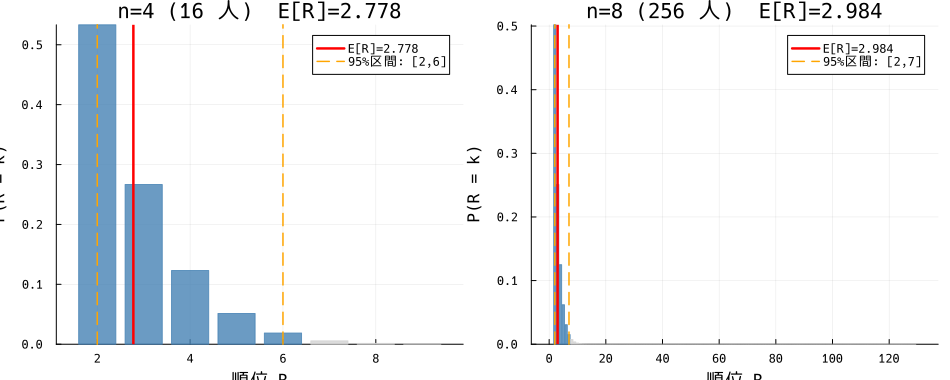

In [18]:
# ===== 可視化 1: n=4, n=8 の確率分布 =====

p_list = []

for n in [4, 8]
    N = 2^n
    ks, probs = pmf_runner_up(n)
    L, U, _ = theoretical_ci95(n)
    E_theo = theoretical_mean(n)

    colors = [L <= k <= U ? :steelblue : :lightgray for k in ks]

    p = bar(ks, probs,
        color=colors, alpha=0.8,
        xlabel="順位 R", ylabel="P(R = k)",
        title="n=$n ($N 人)  E[R]=$(round(E_theo,digits=3))",
        label="", linecolor=:match)

    vline!(p, [E_theo], color=:red, linewidth=2.5,
        label="E[R]=$(round(E_theo,digits=3))")
    vline!(p, [L, U], color=:orange, linewidth=1.5, linestyle=:dash,
        label="95%区間: [$L,$U]")

    push!(p_list, p)
end

plot(p_list..., layout=(1, 2), size=(950, 380), legend=:topright)

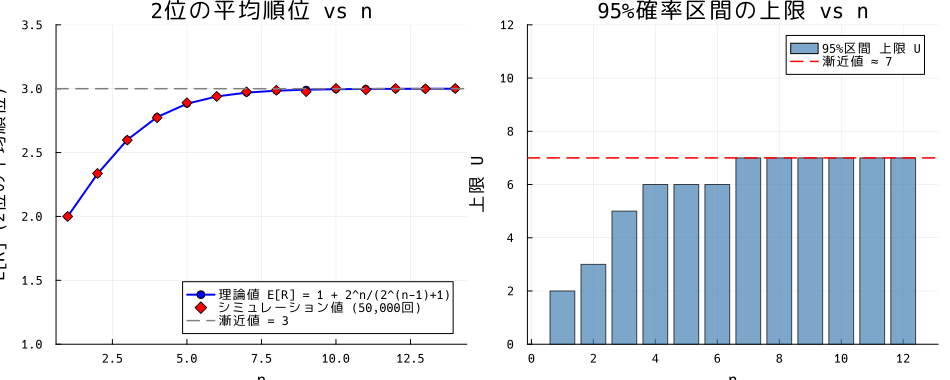

In [19]:
# ===== 可視化 2: E[R] の n 依存性 =====

ns = 1:14
theo_means_v = [theoretical_mean(n) for n in ns]

Random.seed!(123)
sim_means_v = [mean(simulate_runner_up(n, 50_000)) for n in ns]

p1 = plot(ns, theo_means_v,
    label="理論値 E[R] = 1 + 2^n/(2^(n-1)+1)",
    marker=:circle, linewidth=2, color=:blue,
    xlabel="n", ylabel="E[R] (2位の平均順位)",
    title="2位の平均順位 vs n",
    ylims=(1.0, 3.5))

scatter!(p1, ns, sim_means_v,
    label="シミュレーション値 (50,000回)",
    marker=:diamond, markersize=5, color=:red)

hline!(p1, [3.0], color=:gray, linestyle=:dash,
    label="漸近値 = 3", linewidth=1.5)

# ===== 可視化 3: 95%確率区間の上限 U の n 依存性 =====

upper_bounds = [theoretical_ci95(n)[2] for n in 1:12]

p2 = bar(1:12, upper_bounds,
    label="95%区間 上限 U",
    xlabel="n", ylabel="上限 U",
    title="95%確率区間の上限 vs n",
    color=:steelblue, alpha=0.7,
    ylims=(0, 12))

hline!(p2, [7.0], color=:red, linestyle=:dash,
    label="漸近値 ≈ 7", linewidth=1.5)

plot(p1, p2, layout=(1, 2), size=(950, 380))

In [20]:
# ===== まとめ =====

println("="^60)
println("まとめ")
println("="^60)
println()
println("【問(1) 2位の人の平均順位（理論値）】")
println()
println("  E[R] = 1 + 2^n / (2^(n-1) + 1) = (3·2^(n-1) + 1) / (2^(n-1) + 1)")
println()
println("  n=1 (2人):  E[R] = 2")
println("  n=2 (4人):  E[R] = 7/3 ≈ 2.333")
println("  n=3 (8人):  E[R] = 13/5 = 2.600")
println("  n=4 (16人): E[R] = 25/9 ≈ 2.778")
println("  n→∞:       E[R] → 3")
println()
println("【問(2) 2位の人の強さの95%確率区間（理論値）】")
println()
println("  PMF: P(R=k) = C(2^n - k, 2^(n-1) - 1) / C(2^n - 1, 2^(n-1))")
println()
println("  2.5%点は常に L = 2（R ≥ 2 は確実，かつ P(R=2) ≈ 1/2 が大きいため）")
println()
for n in [4, 8, 10, 12]
    L, U, cov = theoretical_ci95(n)
    E = theoretical_mean(n)
    @printf("  n=%2d (%5d人): 95%%区間 = [%d, %d],  E[R] = %.4f\n",
            n, 2^n, L, U, E)
end
println()
println("  n が十分大きいとき，R-1 ≈ Geom(1/2) なので 95%確率区間 ≈ [2, 7]")
println("  （幾何分布の97.5%点: 1-(1/2)^(k-1) ≥ 0.975 → k ≥ 7）")

まとめ

【問(1) 2位の人の平均順位（理論値）】

  E[R] = 1 + 2^n / (2^(n-1) + 1) = (3·2^(n-1) + 1) / (2^(n-1) + 1)

  n=1 (2人):  E[R] = 2
  n=2 (4人):  E[R] = 7/3 ≈ 2.333
  n=3 (8人):  E[R] = 13/5 = 2.600
  n=4 (16人): E[R] = 25/9 ≈ 2.778
  n→∞:       E[R] → 3

【問(2) 2位の人の強さの95%確率区間（理論値）】

  PMF: P(R=k) = C(2^n - k, 2^(n-1) - 1) / C(2^n - 1, 2^(n-1))

  2.5%点は常に L = 2（R ≥ 2 は確実，かつ P(R=2) ≈ 1/2 が大きいため）

  n= 4 (   16人): 95%区間 = [2, 6],  E[R] = 2.7778
  n= 8 (  256人): 95%区間 = [2, 7],  E[R] = 2.9845
  n=10 ( 1024人): 95%区間 = [2, 7],  E[R] = 2.9961
  n=12 ( 4096人): 95%区間 = [2, 7],  E[R] = 2.9990

  n が十分大きいとき，R-1 ≈ Geom(1/2) なので 95%確率区間 ≈ [2, 7]
  （幾何分布の97.5%点: 1-(1/2)^(k-1) ≥ 0.975 → k ≥ 7）
